# 🧠 ANN on Sleep Health & Lifestyle Dataset
### Built with PyTorch | EDA + Full Pipeline

**Dataset:** Sleep Health and Lifestyle Dataset (Kaggle)  
**Problem:** Multi-class Classification → Predict Sleep Disorder (None / Insomnia / Sleep Apnea)  
**Framework:** PyTorch  

---


## 📦 Cell 1 — Import Libraries
> We import all the libraries we need upfront.
> - `pandas`, `numpy` → data handling
> - `matplotlib`, `seaborn` → visualization
> - `sklearn` → preprocessing & evaluation
> - `torch` → building and training our ANN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


✅ All libraries imported successfully!
PyTorch version: 2.11.0+cu128
Using device: GPU (CUDA)


## 📂 Cell 2 — Load the Dataset
> We load the CSV into a pandas DataFrame and do an initial inspection.
> `shape` tells us rows × columns.
> `head()` shows the first 5 rows so we can see what the data looks like.

In [ ]:
df = pd.read_csv(r"/content/Sleep_health_and_lifestyle_dataset.csv")

print("📊 Dataset Shape:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
df.head()

📊 Dataset Shape: (374, 13)

📋 Columns: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 🔍 Cell 3 — Basic Dataset Info
> `info()` shows us column names, data types (int, float, object), and non-null counts.
> This is the first check to understand what preprocessing we'll need.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


## 📈 Cell 4 — Statistical Summary
> `describe()` gives us count, mean, std, min, max, and quartiles for all numerical columns.
> This helps spot outliers, skewed distributions, and scale differences between features.

In [ ]:
df.describe().round(2)


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


## ❓ Cell 5 — Check Missing Values
> 219 rows in `Sleep Disorder` are NaN — but that's NOT missing data!
> NaN here means the person has **NO sleep disorder**.
> We'll fill it with 'None' to make it a proper 3-class target.

In [ ]:
print("🔍 Missing values per column:")
print(df.isnull().sum())

print("\n📌 Target class distribution (before filling NaN):")
print(df['Sleep Disorder'].value_counts(dropna=False))

# Fill NaN in Sleep Disorder → means "No Disorder"
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("\n✅ After filling NaN:")
print(df['Sleep Disorder'].value_counts())


🔍 Missing values per column:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

📌 Target class distribution (before filling NaN):
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

✅ After filling NaN:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


---
## 📊 Exploratory Data Analysis (EDA)
> EDA matlab data ko samajhna — distribution dekhna, patterns dhundna, relationships explore karna.
> Yeh step bahut important hai before model banana.
---

## 🎯 Cell 6 — Target Variable Distribution
> Our target has 3 classes. We visualize how balanced/imbalanced the classes are.
> Imbalanced classes can mislead our model — we should be aware of this.

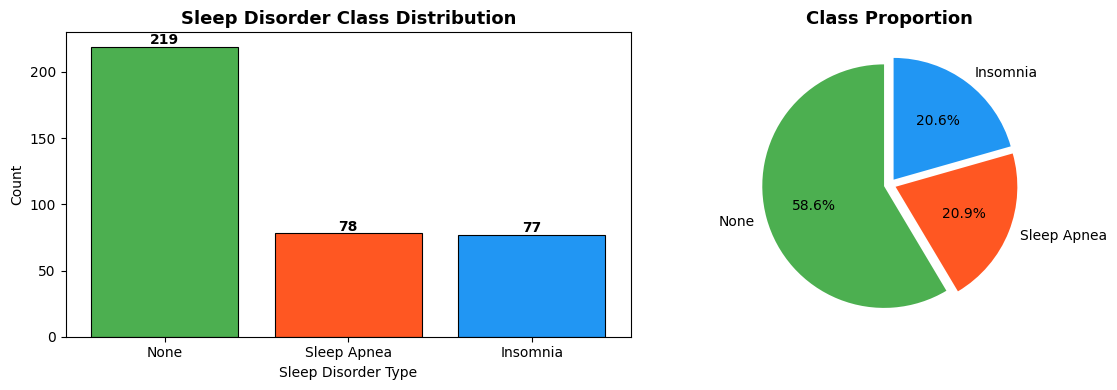


📌 Classes are fairly balanced — great for ANN training!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
colors = ['#4CAF50', '#FF5722', '#2196F3']
counts = df['Sleep Disorder'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sleep Disorder Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sleep Disorder Type')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 2, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*3)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n📌 Classes are fairly balanced — great for ANN training!")


## 👥 Cell 7 — Gender vs Sleep Disorder
> We check if gender has a relationship with sleep disorders.
> Grouped bar charts help us see this cross-distribution clearly.

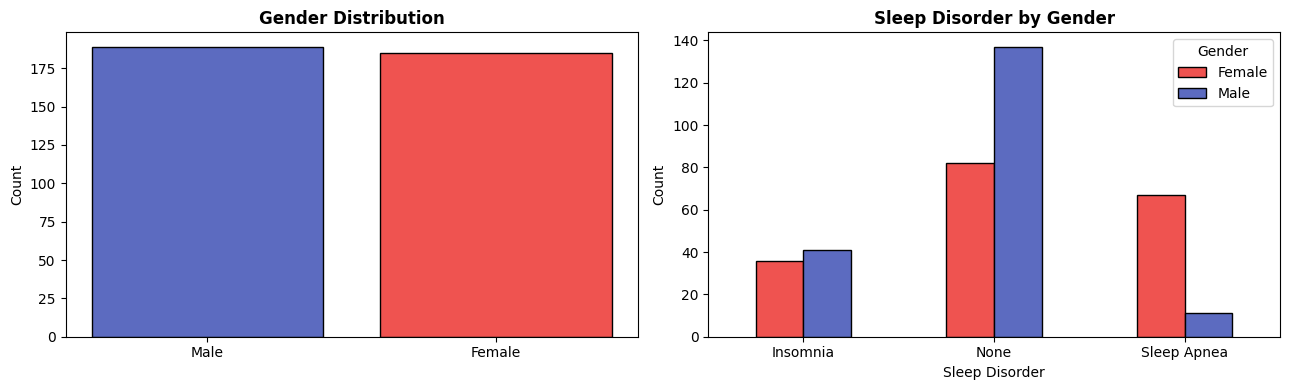

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gender count
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#5C6BC0', '#EF5350'], edgecolor='black')
axes[0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Gender vs Sleep Disorder
pd.crosstab(df['Sleep Disorder'], df['Gender']).plot(
    kind='bar', ax=axes[1], color=['#EF5350', '#5C6BC0'],
    edgecolor='black', rot=0
)
axes[1].set_title('Sleep Disorder by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sleep Disorder')
axes[1].set_ylabel('Count')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


## 📉 Cell 8 — Numerical Feature Distributions
> Histograms show us the distribution shape of each numerical column.
> We check for normality, skewness, and outliers.
> Features with very different scales will be normalized later.

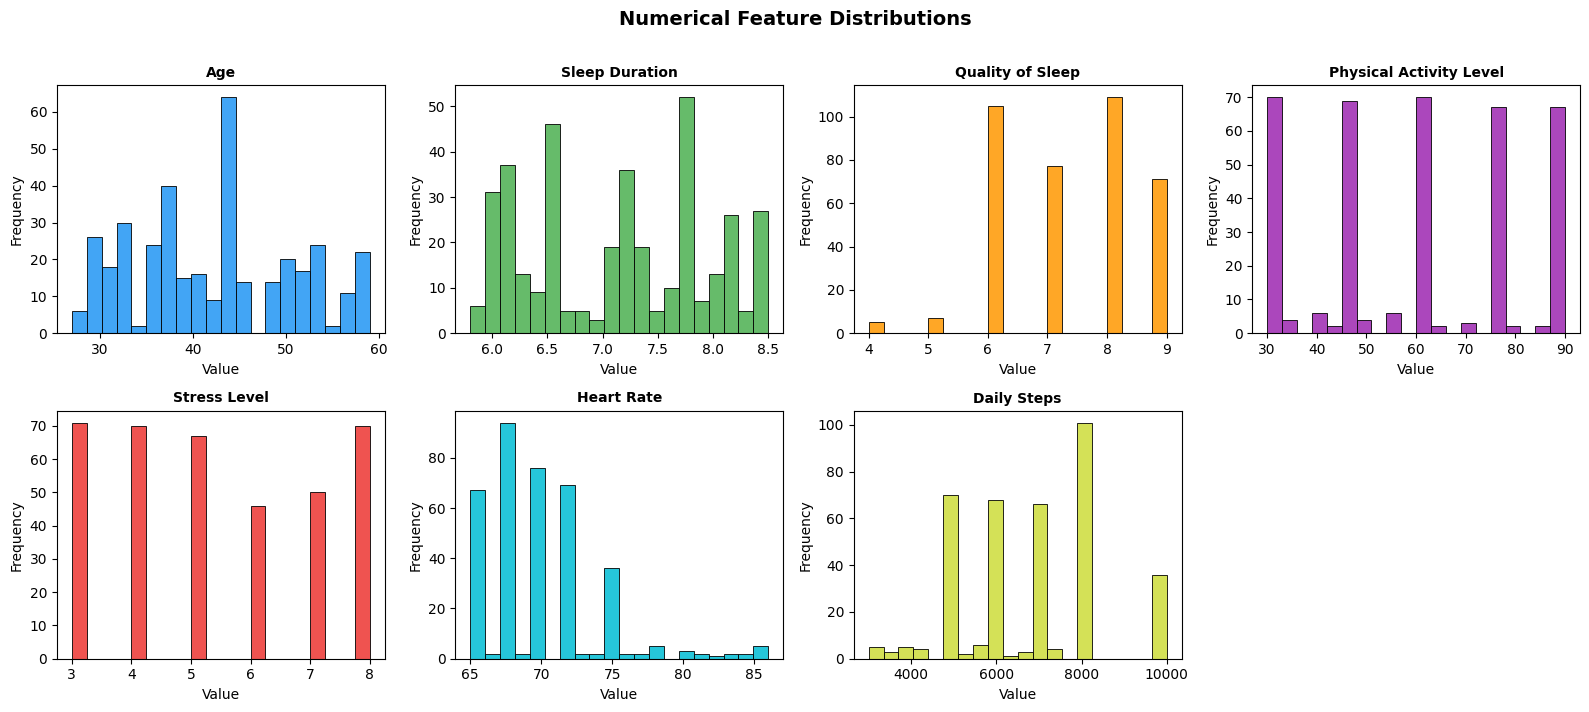

In [ ]:
num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep',
            'Physical Activity Level', 'Stress Level',
            'Heart Rate', 'Daily Steps']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC',
           '#EF5350', '#26C6DA', '#D4E157']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color=palette[i], edgecolor='black', linewidth=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')  # hide last empty subplot
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=100, bbox_inches='tight')
plt.show()


## 🔥 Cell 9 — Correlation Heatmap
> Correlation matrix tells us how strongly two features are linearly related.
> Values close to +1 → strong positive correlation
> Values close to -1 → strong negative correlation
> Values near 0 → no linear relationship
>
> **Why it matters for ANN:** Highly correlated features can cause redundancy.
> ANN handles this internally but knowing correlations helps in feature engineering.

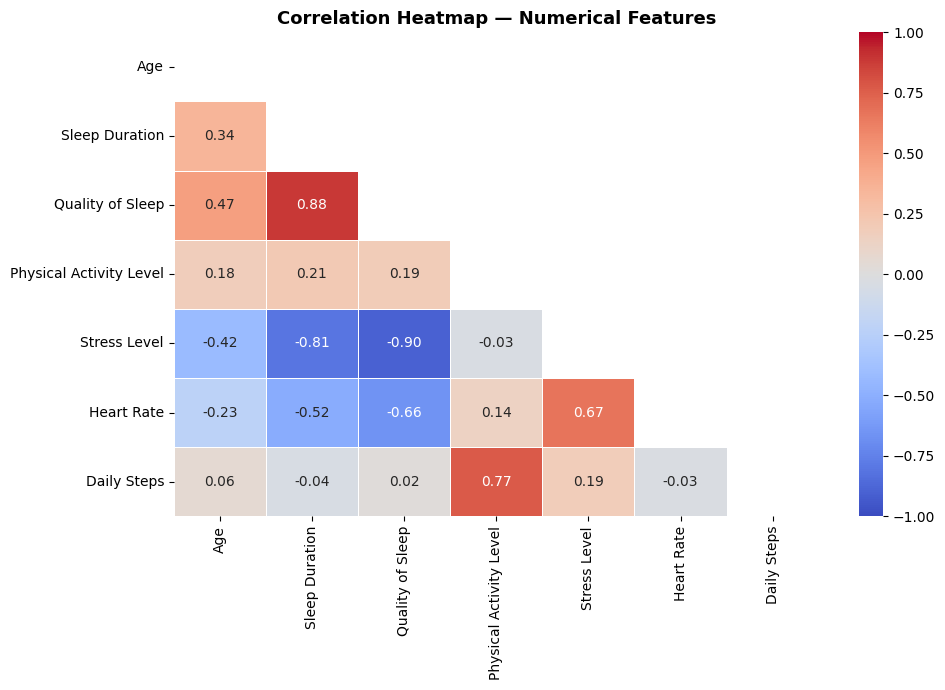


📌 Key observations:
  → Quality of Sleep & Stress Level: Strong negative correlation
  → Sleep Duration & Quality of Sleep: Strong positive correlation


In [ ]:
plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            annot_kws={"size": 10})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📌 Key observations:")
print("  → Quality of Sleep & Stress Level: Strong negative correlation")
print("  → Sleep Duration & Quality of Sleep: Strong positive correlation")


## 📦 Cell 10 — Boxplots: Features vs Sleep Disorder
> Boxplots show the median, IQR (interquartile range), and outliers for each class.
> If boxes for different classes are at different heights → that feature is useful for prediction!

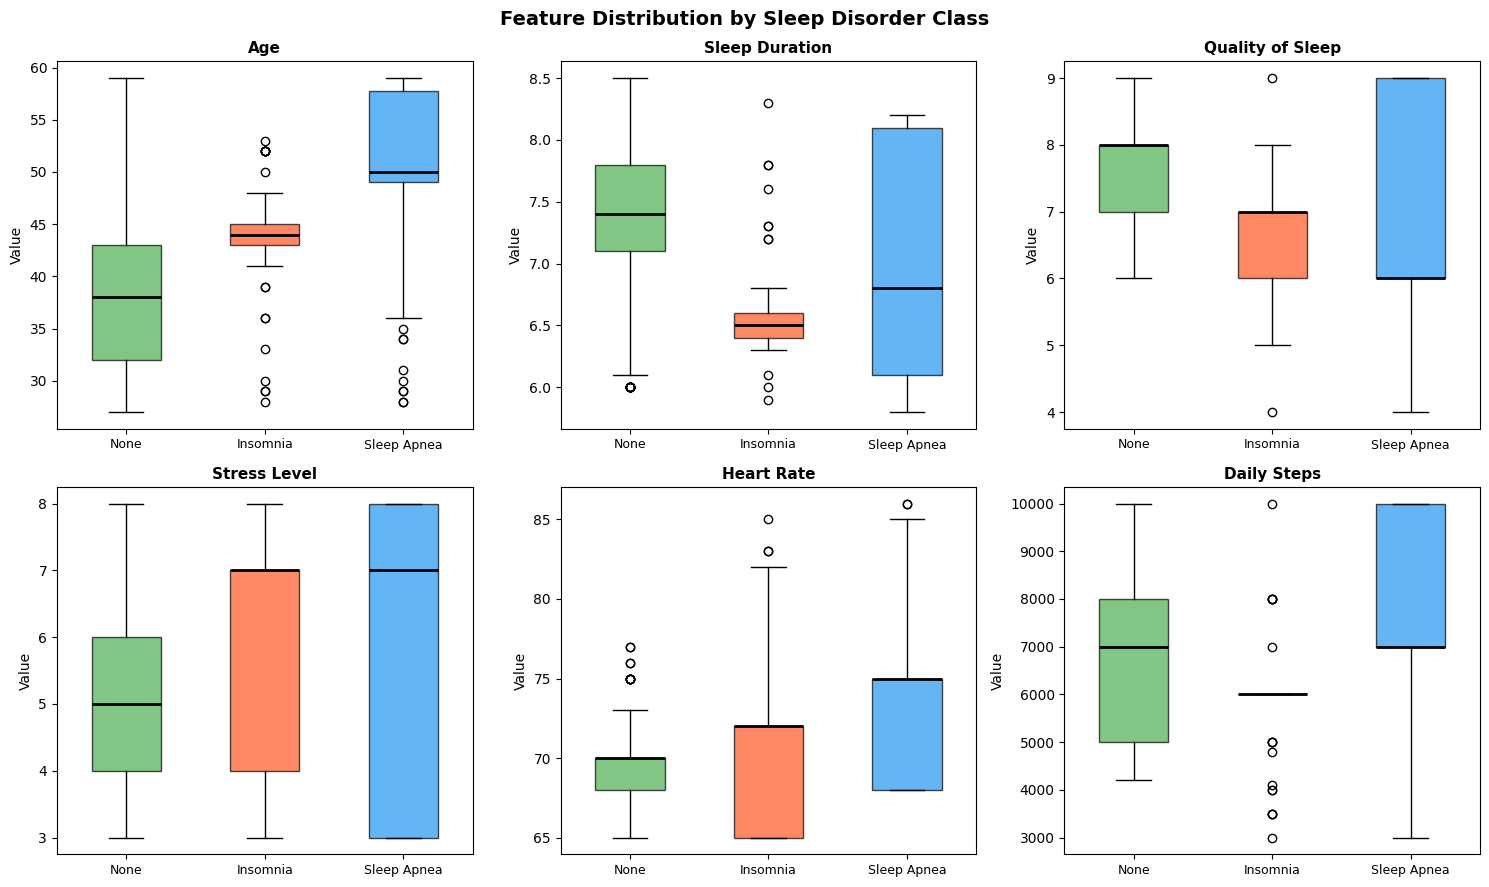

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

box_cols = ['Age', 'Sleep Duration', 'Quality of Sleep',
            'Stress Level', 'Heart Rate', 'Daily Steps']
palette_box = {'None': '#4CAF50', 'Insomnia': '#FF5722', 'Sleep Apnea': '#2196F3'}

for i, col in enumerate(box_cols):
    for disorder, color in palette_box.items():
        subset = df[df['Sleep Disorder'] == disorder][col]
        bp = axes[i].boxplot([subset], positions=[list(palette_box.keys()).index(disorder)],
                             patch_artist=True, widths=0.5,
                             boxprops=dict(facecolor=color, alpha=0.7),
                             medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(['None', 'Insomnia', 'Sleep Apnea'], fontsize=9)
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution by Sleep Disorder Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=100, bbox_inches='tight')
plt.show()


## ⚖️ Cell 11 — BMI Category vs Sleep Disorder
> BMI category is a categorical feature. We check how BMI relates to sleep disorders.
> This helps understand if overweight/obese people are more prone to sleep disorders.

<Figure size 900x500 with 0 Axes>

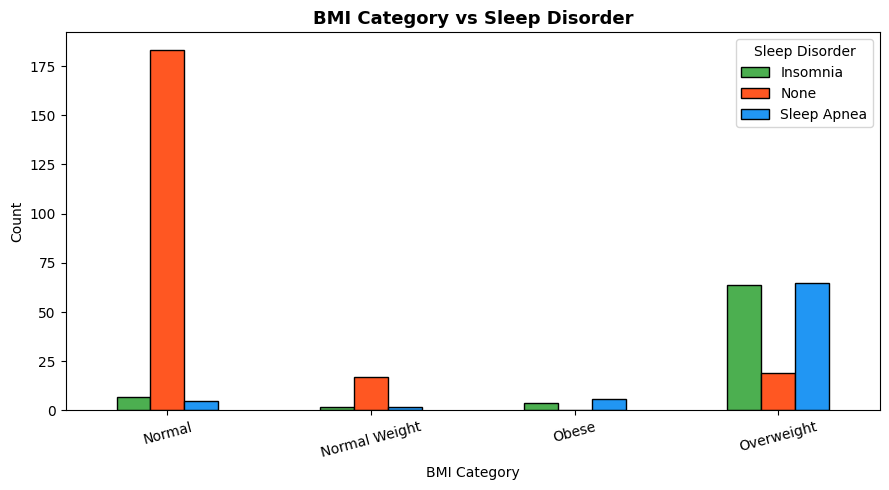

In [ ]:
plt.figure(figsize=(9, 5))
ct = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])
ct.plot(kind='bar', figsize=(9, 5), color=['#4CAF50', '#FF5722', '#2196F3'],
        edgecolor='black', rot=15)
plt.title('BMI Category vs Sleep Disorder', fontsize=13, fontweight='bold')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.legend(title='Sleep Disorder')
plt.tight_layout()
plt.savefig('bmi_vs_disorder.png', dpi=100, bbox_inches='tight')
plt.show()


---
## ⚙️ Data Preprocessing
> Raw data ko ANN ke liye ready karna. Steps:
> 1. Drop irrelevant columns
> 2. Engineer features (Blood Pressure split)
> 3. Label Encode categorical columns
> 4. Scale numerical features
> 5. Encode target variable
---

## 🧹 Cell 12 — Drop Irrelevant Columns + Feature Engineering
> `Person ID` is just a row number — it has zero predictive value, so we drop it.
>
> `Blood Pressure` is stored as a string like "126/83".
> We split it into two separate numerical columns: `BP_Systolic` and `BP_Diastolic`.
> ANN cannot work with string values — only numbers.

In [ ]:
# Drop Person ID
df.drop(columns=['Person ID'], inplace=True)

# Split Blood Pressure into two numerical features
df[['BP_Systolic', 'BP_Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)

# Fix BMI Category (merge 'Normal' and 'Normal Weight' → same thing)
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

print("✅ Columns after preprocessing:")
print(df.columns.tolist())
print("\n📊 Shape:", df.shape)
df.head()


✅ Columns after preprocessing:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'BP_Systolic', 'BP_Diastolic']

📊 Shape: (374, 13)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## 🔢 Cell 13 — Label Encoding Categorical Columns
> Neural networks understand only numbers, not strings like "Male" or "Overweight".
> `LabelEncoder` converts each unique category to an integer.
>
> Example:
> - Gender: Male → 1, Female → 0
> - Occupation: Doctor → 2, Engineer → 3, etc.
> - BMI Category: Normal → 0, Obese → 1, Overweight → 2

In [ ]:
cat_cols = ['Gender', 'Occupation', 'BMI Category']
le_dict = {}  # Store encoders for reference

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"✅ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable
le_target = LabelEncoder()
df['Sleep Disorder'] = le_target.fit_transform(df['Sleep Disorder'])
print(f"\n🎯 Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print("   0 = Insomnia, 1 = None, 2 = Sleep Apnea")
df.head()


✅ Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
✅ Occupation: {'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Nurse': np.int64(5), 'Sales Representative': np.int64(6), 'Salesperson': np.int64(7), 'Scientist': np.int64(8), 'Software Engineer': np.int64(9), 'Teacher': np.int64(10)}
✅ BMI Category: {'Normal': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2)}

🎯 Target encoding: {'Insomnia': np.int64(0), 'None': np.int64(1), 'Sleep Apnea': np.int64(2)}
   0 = Insomnia, 1 = None, 2 = Sleep Apnea


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90


## ✂️ Cell 14 — Separate Features (X) and Target (y)
> `X` = all input features the model will learn from
> `y` = the output label the model will try to predict
>
> We also do an 80-20 train-test split.
> 80% data → model sikhega (train)
> 20% data → model evaluate hoga (test)

In [ ]:
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nClass distribution in target:")
for cls, name in zip(sorted(y.unique()), le_target.classes_):
    print(f"  Class {cls} ({name}): {(y == cls).sum()} samples")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Features (X) shape: (374, 12)
Target (y) shape: (374,)

Feature columns: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'BP_Systolic', 'BP_Diastolic']

Class distribution in target:
  Class 0 (Insomnia): 77 samples
  Class 1 (None): 219 samples
  Class 2 (Sleep Apnea): 78 samples

✅ Train size: 299 | Test size: 75


## 📏 Cell 15 — Feature Scaling (StandardScaler)
> Different features have very different ranges:
> - `Age` ranges from 27 to 59
> - `Daily Steps` ranges from 3000 to 10000
>
> If we don't scale, the model will give more importance to larger-range features.
> `StandardScaler` transforms each feature to **mean=0, std=1**.
>
> ⚠️ Important: We fit the scaler ONLY on training data, then transform both train and test.
> This prevents **data leakage** (test data information leaking into training).

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # ONLY transform on test (no fit!)

print("✅ Scaling complete!")
print(f"   Before scaling — Age mean: {X_train['Age'].mean():.2f}, std: {X_train['Age'].std():.2f}")
print(f"   After scaling  — Age mean: {X_train_scaled[:, 2].mean():.4f}, std: {X_train_scaled[:, 2].std():.4f}")


✅ Scaling complete!
   Before scaling — Age mean: 42.26, std: 8.58
   After scaling  — Age mean: 0.0000, std: 1.0000


## 🔥 Cell 16 — Convert to PyTorch Tensors
> PyTorch works with **Tensors** (like numpy arrays but with GPU support and autograd).
>
> - Features (X) → `torch.float32` (decimal numbers)
> - Labels (y) → `torch.long` (integers, required for CrossEntropyLoss)
>
> `TensorDataset` bundles X and y together.
> `DataLoader` creates mini-batches — instead of feeding all 300 rows at once,
> we feed 32 rows at a time (batch_size=32). This is called **mini-batch gradient descent**.

In [ ]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders (mini-batch size = 32)
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Tensors created!")
print(f"   X_train tensor shape: {X_train_tensor.shape}")
print(f"   y_train tensor shape: {y_train_tensor.shape}")
print(f"   Number of batches per epoch: {len(train_loader)}")
print(f"   Input features per sample: {X_train_tensor.shape[1]}")


✅ Tensors created!
   X_train tensor shape: torch.Size([299, 12])
   y_train tensor shape: torch.Size([299])
   Number of batches per epoch: 10
   Input features per sample: 12


## 🧠 Cell 17 — Build the ANN Model
> This is the heart of the code — defining our neural network architecture.
>
> **Architecture:**
> ```
> Input (13 features)
>     ↓
> Dense Layer 1: 64 neurons  + BatchNorm + ReLU + Dropout(0.3)
>     ↓
> Dense Layer 2: 128 neurons + BatchNorm + ReLU + Dropout(0.3)
>     ↓
> Dense Layer 3: 64 neurons  + BatchNorm + ReLU + Dropout(0.2)
>     ↓
> Output Layer: 3 neurons (one per class)
> ```
>
> **Why these choices?**
> - `ReLU` activation: prevents vanishing gradient, most popular for hidden layers
> - `BatchNorm`: normalizes layer outputs, speeds up training, acts as regularizer
> - `Dropout`: randomly deactivates neurons during training → prevents overfitting
> - `Output has 3 neurons`: one for each class (None, Insomnia, Sleep Apnea)
> - No activation on output: `CrossEntropyLoss` applies Softmax internally

In [ ]:
class SleepANN(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, hidden3, num_classes):
        super(SleepANN, self).__init__()

        # Layer 1: input → 64 neurons
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, hidden1),   # Fully connected: input_dim × 64
            nn.BatchNorm1d(hidden1),          # Normalize batch outputs
            nn.ReLU(),                        # Non-linear activation
            nn.Dropout(0.3)                   # 30% neurons randomly turned off
        )

        # Layer 2: 64 → 128 neurons (wider middle layer)
        self.layer2 = nn.Sequential(
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Layer 3: 128 → 64 neurons (narrowing down)
        self.layer3 = nn.Sequential(
            nn.Linear(hidden2, hidden3),
            nn.BatchNorm1d(hidden3),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Output layer: 64 → 3 (one logit per class)
        self.output = nn.Linear(hidden3, num_classes)

    def forward(self, x):
        # Forward pass: data flows through each layer
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output(x)   # Raw logits (no softmax — CrossEntropyLoss handles it)
        return x


# Instantiate the model
INPUT_DIM  = X_train_tensor.shape[1]   # 13 features
NUM_CLASSES = 3                         # None, Insomnia, Sleep Apnea

model = SleepANN(
    input_dim   = INPUT_DIM,
    hidden1     = 64,
    hidden2     = 128,
    hidden3     = 64,
    num_classes = NUM_CLASSES
).to(DEVICE)

print("🧠 Model Architecture:")
print(model)
print(f"\n📊 Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


🧠 Model Architecture:
SleepANN(
  (layer1): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=64, out_features=3, bias=True)
)

📊 Total trainable parameters: 18,115


## ⚙️ Cell 18 — Loss Function & Optimizer
> **Loss Function:** `CrossEntropyLoss`
> - Standard loss for multi-class classification
> - Internally applies Softmax + Negative Log Likelihood
> - Output: single number telling how wrong the model is (lower = better)
>
> **Optimizer:** `Adam`
> - Adam = Adaptive Moment Estimation
> - It adjusts learning rate for each parameter automatically
> - Much better than plain SGD for most problems
> - `lr=0.001` = learning rate (how big each update step is)
>
> **Learning Rate Scheduler:** `ReduceLROnPlateau`
> - If validation loss stops improving → automatically reduce lr
> - Helps model fine-tune in later epochs

In [ ]:
criterion = nn.CrossEntropyLoss()

# Adam optimizer with learning rate 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Reduce LR when training loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print("✅ Loss Function: CrossEntropyLoss (for 3-class classification)")
print("✅ Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print("✅ Scheduler: ReduceLROnPlateau (halves LR if no improvement for 10 epochs)")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 🏋️ Cell 19 — Training Loop
> This is where the model **actually learns** from the data.
>
> **Each epoch (full pass through training data):**
> 1. `model.train()` → enables dropout and batch norm (training mode)
> 2. Forward pass → model makes predictions
> 3. Loss is calculated → how wrong is it?
> 4. `optimizer.zero_grad()` → clear previous gradients
> 5. `loss.backward()` → backpropagation (compute gradients)
> 6. `optimizer.step()` → update weights using gradients
>
> We track train loss and test accuracy every epoch to monitor progress.

In [ ]:
EPOCHS = 100

train_losses = []
test_accuracies = []

print(f"🏋️ Training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()  # Training mode (enables dropout, batch norm with batch stats)
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        # Step 1: Forward pass — get predictions
        predictions = model(X_batch)

        # Step 2: Compute loss
        loss = criterion(predictions, y_batch)

        # Step 3: Clear old gradients
        optimizer.zero_grad()

        # Step 4: Backpropagation — compute gradients
        loss.backward()

        # Step 5: Update model weights
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on test set
    model.eval()  # Evaluation mode (disables dropout, uses running stats in BN)
    correct = 0
    total = 0
    with torch.no_grad():  # No gradient computation needed during evaluation
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)  # Get class with highest logit
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    test_acc = 100 * correct / total
    test_accuracies.append(test_acc)

    # Update scheduler
    scheduler.step(avg_train_loss)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_train_loss:.4f}  Test Accuracy: {test_acc:.2f}%")

print("\n✅ Training complete!")


## 📉 Cell 20 — Training Curves
> Visualizing how loss and accuracy changed over epochs.
>
> - **Loss curve:** Should decrease and stabilize → model is learning
> - **Accuracy curve:** Should increase and stabilize → model is improving
>
> If loss drops but accuracy doesn't improve → class imbalance or bad features.
> If both plateau early → model may need more capacity (more neurons/layers).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training Loss
axes[0].plot(train_losses, color='#EF5350', linewidth=2)
axes[0].set_title('Training Loss over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.4)
axes[0].fill_between(range(len(train_losses)), train_losses, alpha=0.1, color='#EF5350')

# Test Accuracy
axes[1].plot(test_accuracies, color='#42A5F5', linewidth=2)
axes[1].set_title('Test Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.4)
axes[1].fill_between(range(len(test_accuracies)), test_accuracies, alpha=0.1, color='#42A5F5')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n📌 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📌 Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"📌 Best Test Accuracy: {max(test_accuracies):.2f}%")


## 🎯 Cell 21 — Final Model Evaluation
> Now we evaluate the fully trained model on the test set.
>
> `model.eval()` → switches off dropout (all neurons active for prediction)
> `torch.no_grad()` → tells PyTorch not to track gradients (saves memory)
>
> We collect all predictions and true labels to compute metrics.

In [ ]:
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

final_acc = accuracy_score(all_true, all_preds)
print(f"✅ Final Test Accuracy: {final_acc * 100:.2f}%")
print("\n" + "="*55)
print("📊 CLASSIFICATION REPORT")
print("="*55)
print(classification_report(all_true, all_preds, target_names=le_target.classes_))


## 🔲 Cell 22 — Confusion Matrix
> Confusion matrix shows exactly WHERE the model is making mistakes.
>
> **Reading it:**
> - Diagonal = correct predictions ✅
> - Off-diagonal = misclassifications ❌
>
> Example: If row=Insomnia, col=None has value 3 → model predicted "None" for 3 actual Insomnia cases.

In [ ]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=1, linecolor='gray',
            annot_kws={"size": 13, "fontweight": "bold"})
plt.title('Confusion Matrix — ANN Predictions', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


## 📊 Cell 23 — Per-Class Accuracy Bar Chart
> Overall accuracy can be misleading. Let's see how well the model does per class.
> This tells us if the model is biased towards one class.

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
class_names = le_target.classes_

plt.figure(figsize=(7, 4))
bars = plt.bar(class_names, per_class_acc,
               color=['#4CAF50', '#FF5722', '#2196F3'],
               edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Per-Class Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Sleep Disorder Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()


## 💾 Cell 24 — Save the Model
> We save the trained model weights using `torch.save()`.
> `state_dict()` = dictionary of all learned weights and biases.
>
> Later you can load it with `model.load_state_dict(torch.load('sleep_ann_model.pth'))` without retraining!

In [ ]:
torch.save(model.state_dict(), 'sleep_ann_model.pth')
print("✅ Model saved as 'sleep_ann_model.pth'")

# Demo: Reload and predict on one sample
model_loaded = SleepANN(INPUT_DIM, 64, 128, 64, NUM_CLASSES).to(DEVICE)
model_loaded.load_state_dict(torch.load('sleep_ann_model.pth', map_location=DEVICE))
model_loaded.eval()

# Pick one test sample and predict
sample = X_test_tensor[0].unsqueeze(0).to(DEVICE)  # Add batch dimension
with torch.no_grad():
    logits = model_loaded(sample)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()

print(f"\n🔮 Sample Prediction Demo:")
print(f"   Predicted Class : {le_target.classes_[predicted_class]}")
print(f"   True Label      : {le_target.classes_[y_test_tensor[0].item()]}")
print(f"   Probabilities   : {dict(zip(le_target.classes_, probabilities[0].cpu().numpy().round(3)))}")


---
## ✅ Cell 25 — Summary & Key Learnings

```
📌 What we built:
   → A 4-layer ANN using PyTorch for multi-class sleep disorder classification

📌 ANN Architecture:
   Input(13) → Dense(64) → Dense(128) → Dense(64) → Output(3)
   With BatchNorm + ReLU + Dropout in each hidden layer

📌 Key Concepts Covered:
   ✔ EDA: distributions, correlations, boxplots, crosstabs
   ✔ Feature Engineering: Blood Pressure string → two numeric columns
   ✔ Label Encoding + Feature Scaling
   ✔ Train/Test split with stratification
   ✔ PyTorch Tensors + DataLoader (mini-batch training)
   ✔ Model definition using nn.Module
   ✔ CrossEntropyLoss for multi-class classification
   ✔ Adam optimizer + ReduceLROnPlateau scheduler
   ✔ Training loop: forward → loss → zero_grad → backward → step
   ✔ model.eval() + torch.no_grad() for inference
   ✔ Confusion matrix + classification report
   ✔ Saving and loading model weights
```

---
> **Built for students at Sheryians Coding School 🚀**
